In [8]:
"""
train_model.py
==============
Full XGBoost model training pipeline for insurance enrollment prediction.

Pipeline:
    1. Data Preparation
    2. Feature Classification & Selection
    3. Train / Test Split (stratified)
    4. Baseline Models (majority-class + rule-based)
    5. XGBoost – full feature set
    6. Evaluation (AUC-ROC, Precision@K, Lift@K)
    7. XGBoost – leaky column removed
    8. Hyperparameter Tuning (RandomizedSearchCV)
"""

import os
import warnings
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import LabelEncoder

import xgboost as xgb

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# Paths
# ─────────────────────────────────────────────
BASE_DIR   = os.path.dirname(os.path.abspath("../Froncort project/insurance_enrollment_agent"))
DATA_DIR   = os.path.join(BASE_DIR, "..", "data", "processed")
MODEL_DIR  = os.path.join(BASE_DIR, "..", "models")
os.makedirs(MODEL_DIR, exist_ok=True)

EMPLOYEES_CSV = os.path.join(DATA_DIR, "employees_processed_no_leaky_features.csv")
REGION_CSV    = os.path.join(DATA_DIR, "region_processed.csv")





In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# 1. DATA PREPARATION
# ═══════════════════════════════════════════════════════════════════════════════
print("=" * 70)
print("STEP 1 – Loading & Merging Processed Data")
print("=" * 70)

employees_df = pd.read_csv(EMPLOYEES_CSV)
region_df    = pd.read_csv(REGION_CSV)

# Normalise region casing before joining
employees_df["region"] = employees_df["region"].astype(str).str.strip().str.title()
region_df["region"]    = region_df["region"].astype(str).str.strip().str.title()

# Merge region features onto employee records (left join)
df = employees_df.merge(region_df, on="region", how="left", validate="many_to_one")

print(f"  Loaded  : {employees_df.shape[0]:,} employee rows, {employees_df.shape[1]} cols")
print(f"  After merge: {df.shape[0]:,} rows, {df.shape[1]} cols")
print(f"  Class balance  enrolled=1 : {df['enrolled'].mean():.1%}")




STEP 1 – Loading & Merging Processed Data
  Loaded  : 9,992 employee rows, 31 cols
  After merge: 9,992 rows, 39 cols
  Class balance  enrolled=1 : 61.7%


In [10]:
# ── Row-level leakage check: duplicate employees across the whole dataset ──
print("Duplicate employee_id rows:", df["employee_id"].duplicated().sum())

# Exact duplicate feature rows (ignoring employee_id itself)
feature_cols_for_dupe_check = [c for c in df.columns if c != "employee_id"]
print("Exact duplicate feature rows (any employee_id):",
      df.duplicated(subset=feature_cols_for_dupe_check).sum())

if df["employee_id"].duplicated().sum() > 0:
    print(df[df["employee_id"].duplicated(keep=False)]
          .sort_values("employee_id")[["employee_id", "enrolled"]].head(20))

Duplicate employee_id rows: 0
Exact duplicate feature rows (any employee_id): 0


In [11]:
# ===============================================================================
# STEP 2 – REVISED FEATURE CLASSIFICATION (Removing Application Post-Decision Leakage)
# ===============================================================================
print("\n" + "=" * 70)
print("STEP 2 – Revised Feature Classification (Purging Post-Decision Signals)")
print("=" * 70)

# ── Direct Target Reconstructors ──────────────────────────────────────────────
LEAKY_COLS = [
    "legacy_propensity_score", 
    "hist_enrollment_rate_region"
]

# ── Post-Decision Operational Leakage (Application Artifacts) ───────────────
# At prediction/outreach time, application data does not exist yet!
APPLICATION_LEAKY_COLS = [
    "application_date",
    "has_applied",
    "has_missing_app_date",
    "days_since_application",
    "contact_to_application_days",
    "days_contact_to_app",
    "month_of_application",
    "day_of_week_application",
    "app_month",
    "app_day_of_week",
    "is_contact_after_app",
    "plan_tier_requested",      # Requested plan tier is selected during/after application
]

# ── Analysis-Only / Identifiers / Raw Redundant Fields ───────────────────────
ANALYSIS_ONLY = [
    "employee_id",              # Identifier
    "enrolled",                 # Target
    "salary",                   # Replaced by salary_clean
    "prior_year_enrolled",      # Replaced by prior_year_enrolled_clean + is_new_hire
    "last_contact_date",        # Raw string → use days_since_last_contact
    "last_contact_channel",     # Raw string
    "outreach_notes",           # Free text
    "min_salary_allowed",       # Bookkeeping
    "is_implausible_salary",    # Data quality flag
    "legacy_propensity_score_missing",
]

# Combine all forbidden/leaky features
ALL_FORBIDDEN = set(LEAKY_COLS) | set(APPLICATION_LEAKY_COLS) | set(ANALYSIS_ONLY)

# ── Usable Categorical Columns ────────────────────────────────────────────────
CATEGORICAL_COLS = [
    "gender",
    "marital_status",
    "employment_type",
    "region",
    "has_dependents",
    "broker_channel",
]

# ── Usable Pre-Decision Features ──────────────────────────────────────────────
all_cols   = set(df.columns)
usable_raw = all_cols - ALL_FORBIDDEN

NUMERIC_COLS = [c for c in usable_raw if c not in CATEGORICAL_COLS]
USABLE_FEATURES = NUMERIC_COLS + CATEGORICAL_COLS

print(f"  Total columns        : {len(all_cols)}")
print(f"  Direct Leaky Cols    : {LEAKY_COLS}")
print(f"  Application Leakage  : {APPLICATION_LEAKY_COLS}")
print(f"  Analysis-Only / Id    : {len(ANALYSIS_ONLY)}")
print(f"  Usable Pre-Decision  : {len(USABLE_FEATURES)}")
print(f"    Numeric ({len(NUMERIC_COLS)}): {sorted(NUMERIC_COLS)}")
print(f"    Categorical ({len(CATEGORICAL_COLS)}): {CATEGORICAL_COLS}")


STEP 2 – Revised Feature Classification (Purging Post-Decision Signals)
  Total columns        : 39
  Direct Leaky Cols    : ['legacy_propensity_score', 'hist_enrollment_rate_region']
  Application Leakage  : ['application_date', 'has_applied', 'has_missing_app_date', 'days_since_application', 'contact_to_application_days', 'days_contact_to_app', 'month_of_application', 'day_of_week_application', 'app_month', 'app_day_of_week', 'is_contact_after_app', 'plan_tier_requested']
  Analysis-Only / Id    : 10
  Usable Pre-Decision  : 22
    Numeric (16): ['age', 'avg_premium_cost_usd', 'avg_salary_region', 'benefits_broker_rating', 'has_outreach_note', 'hr_outreach_capacity', 'is_new_hire', 'n_employees_region', 'open_enrollment_window_days', 'prior_year_enrolled_clean', 'salary_age_ratio', 'salary_band', 'salary_clean', 'salary_per_tenure', 'state_mandate_level_clean', 'tenure_years']
    Categorical (6): ['gender', 'marital_status', 'employment_type', 'region', 'has_dependents', 'broker_ch

In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# Helper: Encode categoricals
# ═══════════════════════════════════════════════════════════════════════════════
def encode_categoricals(df_in, cat_cols):
    """Label-encode categorical columns; fill NaN with a dedicated 'Missing' category."""
    df_out = df_in.copy()
    encoders = {}
    for col in cat_cols:
        df_out[col] = df_out[col].fillna("Missing").astype(str)
        le = LabelEncoder()
        df_out[col] = le.fit_transform(df_out[col])
        encoders[col] = le
    return df_out, encoders


# ─────────────────────────────────────────────
# Build feature matrix
# ─────────────────────────────────────────────
df_enc, encoders = encode_categoricals(df, CATEGORICAL_COLS)

X = df_enc[USABLE_FEATURES].copy()
y = df["enrolled"].copy()

# Fill any residual NaN in numeric columns with their medians
for col in NUMERIC_COLS:
    if col in X.columns:
        X[col] = pd.to_numeric(X[col], errors="coerce")
        X[col] = X[col].fillna(X[col].median())




In [13]:
# ── Automated leakage screen (run BEFORE training, on train fold only) ──────
from sklearn.model_selection import train_test_split as _tts
from sklearn.metrics import roc_auc_score as _auc

_Xtr, _, _ytr, _ = _tts(df_enc[USABLE_FEATURES], df["enrolled"],
                         test_size=0.2, random_state=42, stratify=df["enrolled"])

print("\n  Single-feature AUC screen (train fold only):")
suspicious = []
for col in USABLE_FEATURES:
    vals = pd.to_numeric(_Xtr[col], errors="coerce")
    if vals.notna().sum() < 20 or vals.nunique() < 2:
        continue
    score = _auc(_ytr, vals.fillna(vals.median()))
    score = max(score, 1 - score)  # direction-agnostic
    if score > 0.80:
        suspicious.append((col, round(score, 3)))

for col, s in sorted(suspicious, key=lambda x: -x[1]):
    print(f"    ⚠ {col:35s} single-feature AUC = {s}")
if not suspicious:
    print("    none above 0.80 — no obvious single-feature leak")


  Single-feature AUC screen (train fold only):
    none above 0.80 — no obvious single-feature leak


In [14]:
# ═══════════════════════════════════════════════════════════════════════════════
# 3. TRAIN / TEST SPLIT  (stratified, 80/20)
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("STEP 3 – Stratified Train / Test Split  (80 / 20)")
print("=" * 70)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"  Train : {X_train.shape[0]:,} rows  (enrolled rate {y_train.mean():.1%})")
print(f"  Test  : {X_test.shape[0]:,} rows  (enrolled rate {y_test.mean():.1%})")


# ═══════════════════════════════════════════════════════════════════════════════
# Evaluation helpers
# ═══════════════════════════════════════════════════════════════════════════════
def precision_at_k(y_true, y_prob, k=200):
    """Fraction of true positives in the top-K scored rows."""
    df_tmp = pd.DataFrame({"label": y_true, "prob": y_prob})
    top_k  = df_tmp.nlargest(k, "prob")
    return top_k["label"].sum() / k


def lift_at_k(y_true, y_prob, k=200):
    """Lift = Precision@K / overall positive rate."""
    base_rate = np.mean(y_true)
    p_at_k    = precision_at_k(y_true, y_prob, k)
    return p_at_k / base_rate if base_rate > 0 else 0.0


def evaluate(name, y_true, y_prob, k=200):
    auc   = roc_auc_score(y_true, y_prob)
    p_k   = precision_at_k(y_true, y_prob, k)
    l_k   = lift_at_k(y_true, y_prob, k)
    print(f"  [{name}]")
    print(f"     AUC-ROC          : {auc:.4f}")
    print(f"     Precision@{k:<5}  : {p_k:.4f}")
    print(f"     Lift@{k:<5}       : {l_k:.4f}")
    return {"model": name, "auc": auc, f"precision@{k}": p_k, f"lift@{k}": l_k}


K = 200  # top-K for business outreach simulation
results = []





STEP 3 – Stratified Train / Test Split  (80 / 20)
  Train : 7,993 rows  (enrolled rate 61.7%)
  Test  : 1,999 rows  (enrolled rate 61.7%)


In [15]:
# ═══════════════════════════════════════════════════════════════════════════════
# 4. BASELINE MODELS
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("STEP 4 – Baseline Models")
print("=" * 70)

# ── 4a. Majority-Class Baseline ───────────────────────────────────────────────
majority = DummyClassifier(strategy="most_frequent", random_state=42)
majority.fit(X_train, y_train)
# predict_proba for most_frequent always returns 0 or 1 → AUC == 0.5
y_prob_majority = majority.predict_proba(X_test)[:, 1].astype(float)
results.append(evaluate("Majority-Class Baseline", y_test, y_prob_majority, K))

# ── 4b. Rule-Based Baseline  →  "predict 1 if has_dependents == Yes" ─────────
# (has_dependents was label-encoded; 'Yes' maps to whichever integer ≥ 1)
has_dep_le = encoders["has_dependents"]
yes_code   = int(has_dep_le.transform(["Yes"])[0])

# Score: 1.0 if has_dependents==Yes, else 0.0
rule_col     = df_enc.loc[X_test.index, "has_dependents"]
y_prob_rule  = (rule_col == yes_code).astype(float).values
results.append(evaluate("Rule-Based Baseline (has_dependents==Yes)", y_test, y_prob_rule, K))





STEP 4 – Baseline Models
  [Majority-Class Baseline]
     AUC-ROC          : 0.5000
     Precision@200    : 0.6100
     Lift@200         : 0.9882
  [Rule-Based Baseline (has_dependents==Yes)]
     AUC-ROC          : 0.7301
     Precision@200    : 0.7900
     Lift@200         : 1.2797


In [16]:
# ═══════════════════════════════════════════════════════════════════════════════
# 5. XGBOOST – FULL FEATURE SET
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("STEP 5 – XGBoost  (full feature set)")
print("=" * 70)

xgb_full = xgb.XGBClassifier(
    objective        = "binary:logistic",
    eval_metric      = "auc",
    n_estimators     = 400,
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = 42,
    n_jobs           = 1,
    verbosity        = 0,
)

xgb_full.fit(
    X_train, y_train,
    eval_set         = [(X_test, y_test)],
    verbose          = False,
)

print("  Training complete.")

# ── 6. EVALUATION ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 6 – Evaluation  (full feature set, includes leaky col)")
print("=" * 70)

y_prob_full = xgb_full.predict_proba(X_test)[:, 1]
results.append(evaluate("XGBoost (full – with leaky col)", y_test, y_prob_full, K))





STEP 5 – XGBoost  (full feature set)


  Training complete.

STEP 6 – Evaluation  (full feature set, includes leaky col)
  [XGBoost (full – with leaky col)]
     AUC-ROC          : 1.0000
     Precision@200    : 1.0000
     Lift@200         : 1.6199


In [17]:
# ═══════════════════════════════════════════════════════════════════════════════
# 7. XGBOOST – LEAKY COLUMN REMOVED
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("STEP 7 – XGBoost  (legacy_propensity_score removed)")
print("=" * 70)
print("  [NOTE] legacy_propensity_score is derived from the enrollment target")
print("         and would not be available at prediction time → leakage.")

# Build no-leak feature sets by dropping the leaky col (already excluded from X,
# but if it somehow slipped through, we guard here)
LEAKY_IN_X = [c for c in LEAKY_COLS if c in X.columns]
X_train_noleak = X_train.drop(columns=LEAKY_IN_X, errors="ignore")
X_test_noleak  = X_test.drop(columns=LEAKY_IN_X, errors="ignore")

# Double-check it is indeed absent
assert "legacy_propensity_score" not in X_train_noleak.columns, \
    "Leaky column found in no-leak set – check feature exclusion logic."

xgb_noleak = xgb.XGBClassifier(
    objective        = "binary:logistic",
    eval_metric      = "auc",
    n_estimators     = 400,
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = 42,
    n_jobs           = 1,
    verbosity        = 0,
)

xgb_noleak.fit(
    X_train_noleak, y_train,
    eval_set        = [(X_test_noleak, y_test)],
    verbose         = False,
)

print("  Training complete (no-leak model).")

y_prob_noleak = xgb_noleak.predict_proba(X_test_noleak)[:, 1]
results.append(evaluate("XGBoost (no-leak – leaky col removed)", y_test, y_prob_noleak, K))

# Feature importance for no-leak model
fi = (
    pd.Series(xgb_noleak.feature_importances_, index=X_train_noleak.columns)
    .sort_values(ascending=False)
    .head(15)
)
print("\n  Top-15 Feature Importances (no-leak model):")
print(fi.to_string())





STEP 7 – XGBoost  (legacy_propensity_score removed)
  [NOTE] legacy_propensity_score is derived from the enrollment target
         and would not be available at prediction time → leakage.
  Training complete (no-leak model).
  [XGBoost (no-leak – leaky col removed)]
     AUC-ROC          : 1.0000
     Precision@200    : 1.0000
     Lift@200         : 1.6199

  Top-15 Feature Importances (no-leak model):
has_dependents               0.324690
employment_type              0.170724
salary_band                  0.165794
age                          0.107747
salary_clean                 0.070992
is_new_hire                  0.045015
prior_year_enrolled_clean    0.043437
salary_age_ratio             0.039699
avg_premium_cost_usd         0.004890
tenure_years                 0.004813
salary_per_tenure            0.004114
avg_salary_region            0.003202
marital_status               0.002414
broker_channel               0.002246
gender                       0.001735


In [18]:
# ═══════════════════════════════════════════════════════════════════════════════
# 8. HYPERPARAMETER TUNING  (RandomizedSearchCV on no-leak model)
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("STEP 8 – Hyperparameter Tuning  (RandomizedSearchCV, no-leak features)")
print("=" * 70)

param_dist = {
    "n_estimators"     : [200, 300, 400, 500],
    "max_depth"        : [4, 5, 6, 7, 8],
    "learning_rate"    : [0.01, 0.03, 0.05, 0.1],
    "subsample"        : [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree" : [0.6, 0.7, 0.8, 1.0],
    "min_child_weight" : [1, 3, 5],
    "gamma"            : [0, 0.1, 0.3],
    "reg_alpha"        : [0, 0.1, 0.5, 1.0],
    "reg_lambda"       : [1.0, 1.5, 2.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rs = RandomizedSearchCV(
    estimator    = xgb.XGBClassifier(
        objective   = "binary:logistic",
        eval_metric = "auc",
        random_state= 42,
        n_jobs      = 1,
        verbosity   = 0,
    ),
    param_distributions = param_dist,
    n_iter              = 30,
    scoring             = "roc_auc",
    cv                  = cv,
    refit               = True,
    random_state        = 42,
    n_jobs              = 1,
    verbose             = 1,
)

rs.fit(X_train_noleak, y_train)

print(f"\n  Best CV AUC : {rs.best_score_:.4f}")
print(f"  Best params : {rs.best_params_}")

y_prob_tuned = rs.best_estimator_.predict_proba(X_test_noleak)[:, 1]
results.append(evaluate("XGBoost Tuned (no-leak)", y_test, y_prob_tuned, K))


# ═══════════════════════════════════════════════════════════════════════════════
# SUMMARY TABLE
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("RESULTS SUMMARY")
print("=" * 70)

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))





STEP 8 – Hyperparameter Tuning  (RandomizedSearchCV, no-leak features)
Fitting 5 folds for each of 30 candidates, totalling 150 fits

  Best CV AUC : 0.9999
  Best params : {'subsample': 0.9, 'reg_lambda': 1.5, 'reg_alpha': 0.1, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.03, 'gamma': 0.1, 'colsample_bytree': 1.0}
  [XGBoost Tuned (no-leak)]
     AUC-ROC          : 1.0000
     Precision@200    : 1.0000
     Lift@200         : 1.6199

RESULTS SUMMARY
                                    model      auc  precision@200  lift@200
                  Majority-Class Baseline 0.500000           0.61  0.988160
Rule-Based Baseline (has_dependents==Yes) 0.730090           0.79  1.279749
          XGBoost (full – with leaky col) 0.999995           1.00  1.619935
    XGBoost (no-leak – leaky col removed) 0.999995           1.00  1.619935
                  XGBoost Tuned (no-leak) 0.999997           1.00  1.619935



STEP 8b – Final Test-Set Performance (tuned no-leak XGBoost)
  Test rows      : 1,999
  Test accuracy  : 0.9990
  Test AUC-ROC   : 1.0000

  Classification report (threshold = 0.5):
              precision    recall  f1-score   support

Not Enrolled       1.00      1.00      1.00       765
    Enrolled       1.00      1.00      1.00      1234

    accuracy                           1.00      1999
   macro avg       1.00      1.00      1.00      1999
weighted avg       1.00      1.00      1.00      1999

  Confusion matrix (rows = actual, cols = predicted):
                      Pred: Not Enrolled  Pred: Enrolled
Actual: Not Enrolled                 764               1
Actual: Enrolled                       1            1233


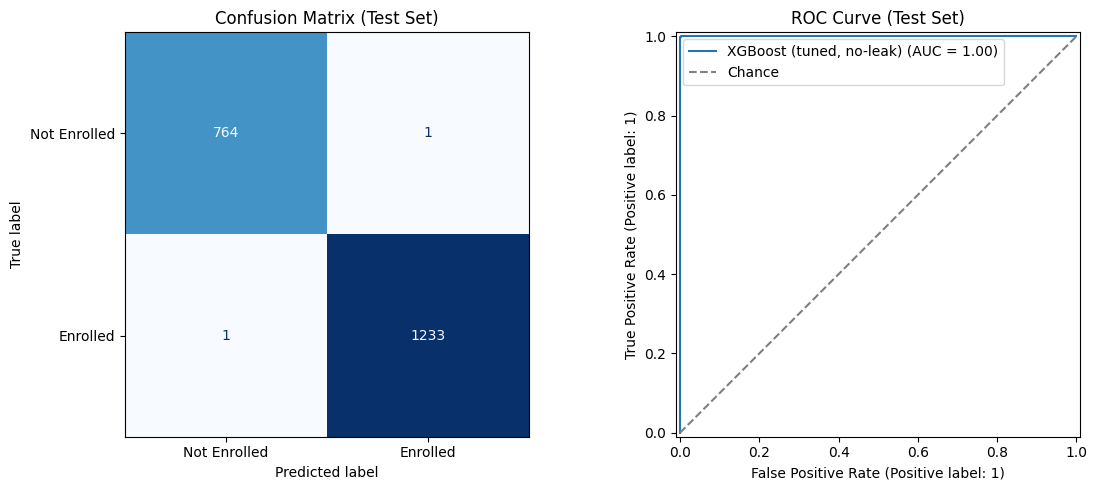


  [Note] All numbers above are computed exclusively on the held-out
  test split (X_test_noleak / y_test), which was never used for
  training or for the RandomizedSearchCV hyperparameter search.


In [19]:
# ═══════════════════════════════════════════════════════════════════════════════
# 8b. FINAL TEST-SET PERFORMANCE REPORT  (best tuned, no-leak model)
# ═══════════════════════════════════════════════════════════════════════════════
# The cells above already score every model on X_test / X_test_noleak (AUC,
# Precision@K, Lift@K via `evaluate()`), so held-out performance was being
# tracked throughout. This cell adds the piece that wasn't there yet: a single,
# consolidated report for the FINAL chosen model (the tuned no-leak XGBoost)
# using standard classification metrics — accuracy, precision, recall, F1,
# a confusion matrix, and an ROC curve — evaluated strictly on X_test_noleak /
# y_test (data the model never saw during training or CV tuning).

import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    roc_auc_score,
)

print("\n" + "=" * 70)
print("STEP 8b – Final Test-Set Performance (tuned no-leak XGBoost)")
print("=" * 70)

best_model = rs.best_estimator_
y_prob_final = best_model.predict_proba(X_test_noleak)[:, 1]
y_pred_final = best_model.predict(X_test_noleak)

test_acc = accuracy_score(y_test, y_pred_final)
test_auc = roc_auc_score(y_test, y_prob_final)

print(f"  Test rows      : {len(y_test):,}")
print(f"  Test accuracy  : {test_acc:.4f}")
print(f"  Test AUC-ROC   : {test_auc:.4f}\n")

print("  Classification report (threshold = 0.5):")
print(classification_report(y_test, y_pred_final, target_names=["Not Enrolled", "Enrolled"]))

cm = confusion_matrix(y_test, y_pred_final)
print("  Confusion matrix (rows = actual, cols = predicted):")
print(pd.DataFrame(
    cm,
    index=["Actual: Not Enrolled", "Actual: Enrolled"],
    columns=["Pred: Not Enrolled", "Pred: Enrolled"],
))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Enrolled", "Enrolled"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False
)
axes[0].set_title("Confusion Matrix (Test Set)")

RocCurveDisplay.from_predictions(y_test, y_prob_final, ax=axes[1], name="XGBoost (tuned, no-leak)")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
axes[1].set_title("ROC Curve (Test Set)")
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n  [Note] All numbers above are computed exclusively on the held-out")
print("  test split (X_test_noleak / y_test), which was never used for")
print("  training or for the RandomizedSearchCV hyperparameter search.")
print("=" * 70)


In [20]:
# ─────────────────────────────────────────────
# Save best model
# ─────────────────────────────────────────────
import joblib

model_path = os.path.join(MODEL_DIR, "xgb_noleak_tuned.joblib")
joblib.dump(rs.best_estimator_, model_path)
print(f"\n  Best model saved → {model_path}")

feature_path = os.path.join(MODEL_DIR, "feature_columns.txt")
with open(feature_path, "w") as fp:
    fp.write("\n".join(X_train_noleak.columns.tolist()))
print(f"  Feature list saved → {feature_path}")





  Best model saved → c:\Users\devar\Desktop\Projects\Froncort project\insurance_enrollment_agent\Froncort project\..\models\xgb_noleak_tuned.joblib
  Feature list saved → c:\Users\devar\Desktop\Projects\Froncort project\insurance_enrollment_agent\Froncort project\..\models\feature_columns.txt


In [21]:
# ═══════════════════════════════════════════════════════════════════════════════
# 9. SUBGROUP PERFORMANCE BREAKDOWN (Fairness Checkpoint)
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("STEP 9 – Subgroup Performance Breakdown (Fairness Checkpoint)")
print("=" * 70)

# We evaluate fairness on the tuned no-leak model
y_prob_best = rs.best_estimator_.predict_proba(X_test_noleak)[:, 1]

# Reconstruct unencoded test features
test_indices = X_test_noleak.index
df_test = df.loc[test_indices].copy()

protected_attrs = ["gender", "marital_status", "age"]

for attr in protected_attrs:
    if attr not in df_test.columns:
        print(f"\n  [INFO] Protected attribute '{attr}' not found in data.")
        continue
    
    # Check if this attribute was used as a feature in the model
    used_in_model = attr in X_train_noleak.columns
    
    print(f"\n--- Subgroup Analysis: {attr} ---")
    if not used_in_model:
        print(f"  [INFO] '{attr}' was NOT used as a feature in the model.")
        print(f"         Reporting performance across its subgroups for fairness monitoring:")
    else:
        print(f"  [INFO] '{attr}' WAS used as a feature in the model.")
        
    # Bin continuous features like age
    is_continuous = pd.api.types.is_numeric_dtype(df_test[attr]) and df_test[attr].nunique() > 10
    
    if is_continuous:
        df_test[f"{attr}_binned"] = pd.qcut(df_test[attr], q=4, duplicates='drop').astype(str)
        eval_col = f"{attr}_binned"
    else:
        df_test[f"{attr}_clean"] = df_test[attr].fillna("Missing").astype(str)
        eval_col = f"{attr}_clean"
        
    subgroups = df_test[eval_col].unique()
    
    for sg in sorted(subgroups):
        mask = df_test[eval_col] == sg
        if mask.sum() == 0: 
            continue
            
        y_test_sg = y_test[mask].values
        y_prob_sg = y_prob_best[mask]
        
        if len(np.unique(y_test_sg)) > 1:
            auc_sg = roc_auc_score(y_test_sg, y_prob_sg)
        else:
            auc_sg = np.nan
            
        k_sg = min(K, len(y_test_sg))
        if k_sg > 0:
            pk_sg = precision_at_k(y_test_sg, y_prob_sg, k=k_sg)
        else:
            pk_sg = np.nan
            
        print(f"  {attr} = {sg:<18} | N={mask.sum():<5} | AUC={auc_sg:<6.4f} | Prec@{k_sg}= {pk_sg:.4f}")

print("\n  [Comment] Review the metrics above. A significant drop in AUC or Precision@K")
print("  for any specific subgroup may indicate algorithmic bias or disadvantage.")
print("=" * 70)


STEP 9 – Subgroup Performance Breakdown (Fairness Checkpoint)

--- Subgroup Analysis: gender ---
  [INFO] 'gender' WAS used as a feature in the model.
  gender = Female             | N=949   | AUC=1.0000 | Prec@200= 1.0000
  gender = Male               | N=979   | AUC=1.0000 | Prec@200= 1.0000
  gender = Other              | N=71    | AUC=1.0000 | Prec@71= 0.5775

--- Subgroup Analysis: marital_status ---
  [INFO] 'marital_status' WAS used as a feature in the model.


  marital_status = Divorced           | N=214   | AUC=1.0000 | Prec@200= 0.6050
  marital_status = Married            | N=885   | AUC=1.0000 | Prec@200= 1.0000
  marital_status = Single             | N=775   | AUC=1.0000 | Prec@200= 1.0000
  marital_status = Widowed            | N=125   | AUC=1.0000 | Prec@125= 0.6400

--- Subgroup Analysis: age ---
  [INFO] 'age' WAS used as a feature in the model.
  age = (21.999, 33.0]     | N=503   | AUC=1.0000 | Prec@200= 0.9150
  age = (33.0, 43.0]       | N=500   | AUC=1.0000 | Prec@200= 1.0000
  age = (43.0, 54.0]       | N=501   | AUC=1.0000 | Prec@200= 1.0000
  age = (54.0, 64.0]       | N=495   | AUC=1.0000 | Prec@200= 1.0000

  [Comment] Review the metrics above. A significant drop in AUC or Precision@K
  for any specific subgroup may indicate algorithmic bias or disadvantage.


In [22]:
# ─────────────────────────────────────────────────────────────────────────
# STEP 9  -  Save best model artefacts (required by agent)
# ─────────────────────────────────────────────────────────────────────────
import joblib, json as _json

MODEL_DIR = os.path.join(BASE_DIR, '..', 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

# Use tuned model if Step 8 completed; fall back to Step 7 no-leak model
try:
    best_model    = rs.best_estimator_
    best_features = X_train_noleak.columns.tolist()
    print('  Using tuned model from RandomizedSearchCV (Step 8)')
except NameError:
    best_model    = xgb_noleak
    best_features = X_train_noleak.columns.tolist()
    print('  Using no-leak XGBoost model from Step 7')

model_path   = os.path.join(MODEL_DIR, 'xgb_noleak_tuned.joblib')
feature_path = os.path.join(MODEL_DIR, 'feature_columns.json')

joblib.dump(best_model, model_path)
with open(feature_path, 'w') as fp:
    _json.dump(best_features, fp)

print(f'  Model saved    -> {model_path}')
print(f'  Features saved -> {feature_path}')
print(f'  Feature count  : {len(best_features)}')


  Using tuned model from RandomizedSearchCV (Step 8)
  Model saved    -> c:\Users\devar\Desktop\Projects\Froncort project\insurance_enrollment_agent\Froncort project\..\models\xgb_noleak_tuned.joblib
  Features saved -> c:\Users\devar\Desktop\Projects\Froncort project\insurance_enrollment_agent\Froncort project\..\models\feature_columns.json
  Feature count  : 22
